### Question 1

**a) 18.56**
- **Fixed<9,3> Representation**: `010010.100`
- **Value**: 18.5  
- **Round-off Error**: $18.56 - 18.5 = 0.06$
- **Potential Problem**: None within range

**b) -7.5**
- **Fixed<9,3> Representation**: `111000.100`
- **Value**: -7.5 (exact)
- **Round-off Error**: $0$
- **Potential Problem**: None

**c) 22.87**
- **Fixed<9,3> Representation**: `010110.111`
- **Value**: 22.875  
- **Round-off Error**: $22.87 - 22.875 = -0.005$
- **Potential Problem**: Minor round-off error

**d) 36.5**
- **Fixed<9,3> Representation**: Overflow (cannot represent)
- **Value**: Maximum representable is 31.875
- **Round-off Error**: $36.5 - 31.875 = 4.625$
- **Potential Problem**: Overflow; number exceeds integer range

---

### Question 2

**a) JRRN Binomial Tree Parameters**<br>
Given: $S_0 = 100$, $r = 5\%$, $\sigma = 15\%$, $T = 2$, $n = 2$ steps
- $\Delta t = 1$
- $u = e^{(r - \sigma^2/2)\Delta t + \sigma\sqrt{\Delta t}} \approx 1.2077$
- $d = e^{(r - \sigma^2/2)\Delta t - \sigma\sqrt{\Delta t}} \approx 0.89472$
- Risk-neutral probability: $p = \frac{e^{r\Delta t} - d}{u - d} \approx 0.50014$

**Tree Structure**
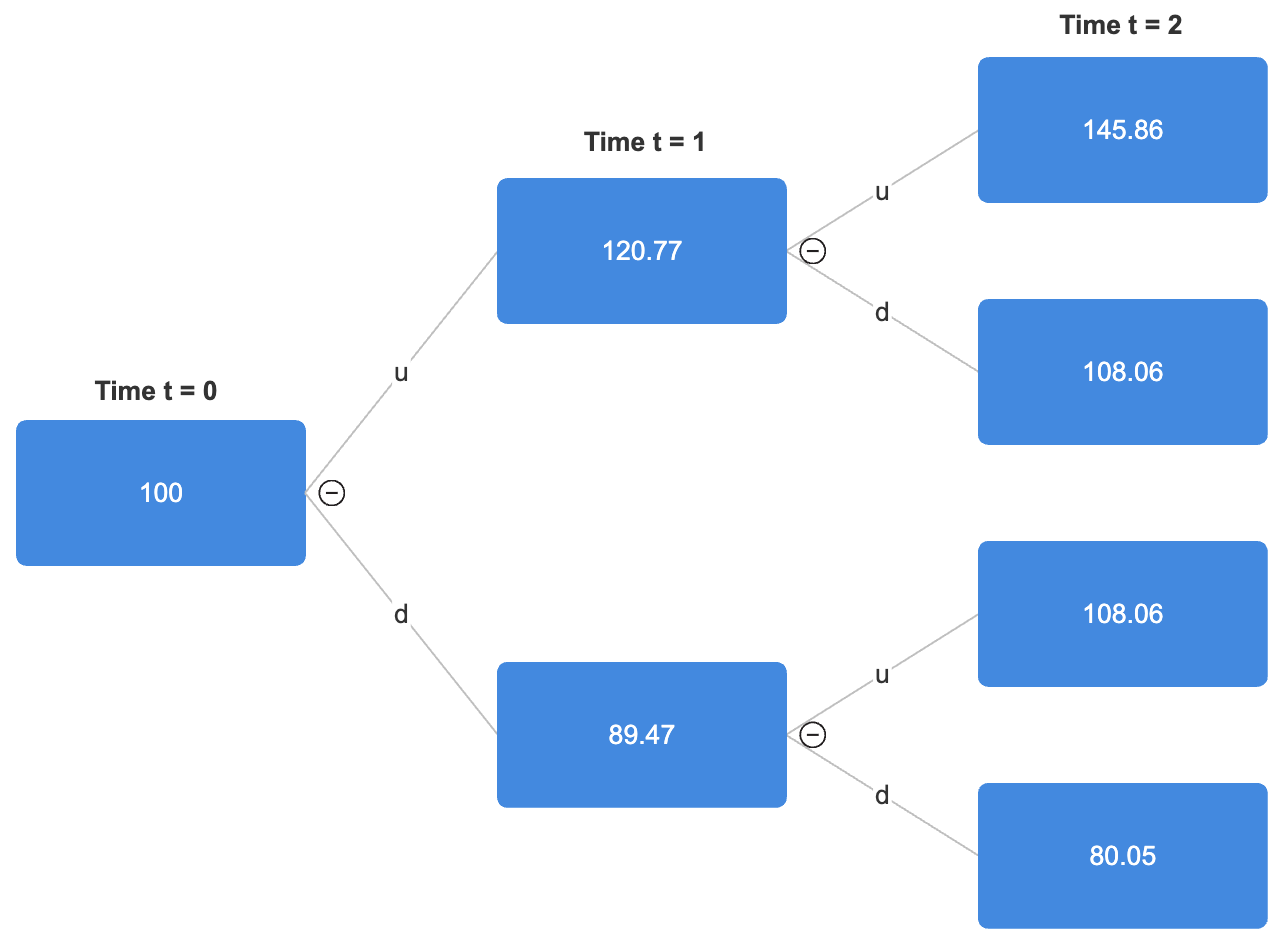

**b) European Put Option (Strike = 105)**
- Terminal Payoffs:
  - $S_0u^2$: $\max(105 - S_0u^2, 0) = 0$
  - $S_0ud=S_0du$: $\max(105 - S_0ud, 0) = \max(105 - S_0du, 0) = 0$
  - $S_0dd$: $\max(105 - S_0d^2, 0) \approx 24.95$
- Backward Induction:
  - Time 1 (up): $(0 \cdot p + 0 \cdot (1-p))e^{-0.05} = 0$
  - Time 1 (down): $(0 \cdot p + 24.95 \cdot (1-p))e^{-0.05} \approx 11.863$
  - Time 0: $(0 \cdot p + 11.863 \cdot (1-p))e^{-0.05} \approx 5.6404$
- **Option Price**: $\approx 5.6404$

---

### Question 3

**Equation**: $f(x) = x^2 - x - 1 = 0$
**Root**: $\phi = \frac{1+\sqrt{5}}{2} \approx 1.618$

**a) Bisection Method (3 Steps)**
- Initial: $[0, 4]$
  - Step 1: $x_3 = 2$. $f(2) = 1 > 0$. New interval: $[0, 2]$
  - Step 2: $x_3 = 1$. $f(1) = -1 < 0$. New interval: $[1, 2]$
  - Step 3: $x_3 = 1.5$. $f(1.5) = -0.25 < 0$. New interval: $[1.5, 2]$
- **Result**: $x \approx 1.5$

**b) Secant Method (2 Steps)**
- Initial: $x_1 = 0$, $x_2 = 4$
  - Step 1: $x_3 = \frac{x_1f(x_2) - x_2f(x_1)}{f(x_2)-f(x_1)} = \frac{1}{3}$. Update: $x_1 = 4$, $x_2 = \frac{1}{3}$
  - Step 2: $x_3 = \frac{x_1f(x_2) - x_2f(x_1)}{f(x_2)-f(x_1)} = 0.7$. Update: $x_1 = \frac{1}{3}$, $x_2 = 0.7$
- **Result**: $x \approx 0.7$

**c) False Position Method (2 Steps)**
- Initial: $[0, 4]$
  - Step 1: $c = \frac{0 \cdot f(4) - 4 \cdot f(0)}{f(4) - f(0)} = \frac{1}{3}$. $f(0)f\left(\frac{1}{3}\right) > 0$. New interval: $\left[\frac{1}{3}, 4\right]$
  - Step 2: $c = \frac{\frac{1}{3} \cdot f(4) - 4 \cdot f\left(\frac{1}{3}\right)}{f(4) - f\left(\frac{1}{3}\right)} = 0.7$. $f\left(\frac{1}{3}\right)f(0.7) > 0$. New interval: $[0.7, 4]$
- **Result**: $x \approx 0.7$

---

### Question 4

**a) Pseudo Code for Monte-Carlo Integration**
```plaintext
Function mcIntegrate(f, a, b, n):
    Initialize sum = 0
    For i = 1 to n:
        Generate x ~ Uniform(a, b)
        sum += f(x)
    integral = (b - a) * (sum / n)
    Return integral
```

**b) Taylor Expansion and Integral of $g(x)$**<br>
The second-order Taylor expansion of $f(x) = \frac{1}{2}e^{-x^2/2}$ at $x=0$:
$$
g(x) = \frac{1}{2} - \frac{1}{4}x^2
$$
Analytical integral over $[0, 2]$:
$$
\int_0^2 g(x)\,dx = \left[ \frac{1}{2}x - \frac{1}{12}x^3 \right]_0^2 = \frac{1}{3}
$$

**c) Python Function with Control Variate**
```python
import numpy as np

def mcIntegrate(f, a, b, g, g_integral, n=100000):
    x_samples = np.random.uniform(a, b, n)
    h = f(x_samples)
    g_samples = g(x_samples)
    
    mean_h = np.mean(h)
    mean_g = np.mean(g_samples)
    cov_hg = np.cov(h, g_samples, ddof=0)[0, 1]
    var_g = np.var(g_samples, ddof=0)
    
    beta = cov_hg / var_g if var_g != 0 else 0
    expected_g = g_integral / (b - a)
    adjustment = beta * (expected_g - mean_g)
    
    integral = (b - a) * (mean_h + adjustment)
    return integral
```

---



### Question 5

**a) Transformed PDE for $\hat{V}_t$**<br>
**Step 1: Define the transformations**<br>
Let $X_t = \ln(S_t/B_t)$ and $\hat{V}_t = V_t/B_t$, where $B_t$ follows $dB_t = rB_t dt$.

**Step 2: Compute $dX_t$ using Itô’s Lemma**<br>
For $S_t$ under the Black-Scholes model:
$$
dS_t = (r - q)S_t dt + \sigma S_t dW_t
$$
Apply Itô’s Lemma to $X_t = \ln(S_t/B_t)$:
$$
dX_t = \frac{\frac{1}{B_t}dS_t - \frac{S_t}{B_t^2}dB_t}{\frac{S_t}{B_t}} - \frac{(dS_t)^2}{2S_t^2} = \left(r - q - \frac{1}{2}\sigma^2\right)dt + \sigma dW_t - r dt = \left(-q - \frac{1}{2}\sigma^2\right)dt + \sigma dW_t
$$
**Step 3: Apply Itô’s Lemma to $\hat{V}_t = V(t, X_t)/B_t$**<br>
Since $B_t$ is deterministic:
$$
d\hat{V}_t = \frac{1}{B_t}dV - \frac{V}{B_t^2}dB_t
$$
Substitute $dV$ from the Black-Scholes PDE:
$$
\frac{\partial V}{\partial t} + (r - q)S\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} - rV = 0
$$
Change variables to $X_t$ and simplify. After substitution and simplification, the PDE becomes:
$$
\boxed{\frac{\partial \hat{V}}{\partial t} - \left(q + \frac{\sigma^2}{2}\right)\frac{\partial \hat{V}}{\partial X} + \frac{1}{2}\sigma^2 \frac{\partial^2 \hat{V}}{\partial X^2} = 0}
$$

**b) Linear System for Implicit Euler Scheme**<br>
**Step 1: Discretize the PDE with Implicit Euler**
Let $\alpha = -\left(q + \frac{\sigma^2}{2}\right)$ and $\beta = \frac{\sigma^2}{2}$. The PDE becomes:
$$
\frac{\partial \hat{V}}{\partial t} + \alpha \frac{\partial \hat{V}}{\partial X} + \beta \frac{\partial^2 \hat{V}}{\partial X^2} = 0
$$
Implicit Euler time discretization:
$$
\frac{\hat{V}^{n+1} - \hat{V}^n}{\Delta t} + \alpha \frac{\partial \hat{V}^{n+1}}{\partial X} + \beta \frac{\partial^2 \hat{V}^{n+1}}{\partial X^2} = 0
$$
Rearranged:
$$
\hat{V}^{n+1} - \hat{V}^n + \Delta t \left(\alpha \frac{\partial \hat{V}^{n+1}}{\partial X} + \beta \frac{\partial^2 \hat{V}^{n+1}}{\partial X^2}\right) = 0
$$

**Step 2: Spatial Discretization with Central Differences**
- **First derivative**:
  $$
  \frac{\partial \hat{V}^{n+1}}{\partial X} \approx \frac{\hat{V}_{i+1}^{n+1} - \hat{V}_{i-1}^{n+1}}{2\Delta X}
  $$
  Matrix $\mathbf{D}_1$ has entries:
  $$
  D_1[i, i-1] = -\frac{1}{2\Delta X}, \quad D_1[i, i+1] = \frac{1}{2\Delta X}
  $$
- **Second derivative**:
  $$
  \frac{\partial^2 \hat{V}^{n+1}}{\partial X^2} \approx \frac{\hat{V}_{i+1}^{n+1} - 2\hat{V}_i^{n+1} + \hat{V}_{i-1}^{n+1}}{(\Delta X)^2}
  $$
  Matrix $\mathbf{D}_2$ has entries:
  $$
  D_2[i, i-1] = \frac{1}{(\Delta X)^2}, \quad D_2[i, i] = -\frac{2}{(\Delta X)^2}, \quad D_2[i, i+1] = \frac{1}{(\Delta X)^2}
  $$

**Step 3: Assemble the Linear System**<br>
The discretized equation becomes:
$$
\left[\mathbf{I} - \Delta t \left(\alpha \mathbf{D}_1 + \beta \mathbf{D}_2\right)\right] \hat{V}^{n+1} = \hat{V}^n,
$$
where $\alpha = -\left(q + \frac{\sigma^2}{2}\right)$, $\beta = \frac{\sigma^2}{2}$, and $\mathbf{D}_1$, $\mathbf{D}_2$ are first and second derivative matrices. This is a **tridiagonal system** of the form:
$$
\boxed{A \hat{V}^{n+1} = \hat{V}^n}, \quad \text{where } A = \mathbf{I} - \Delta t (\alpha \mathbf{D}_1 + \beta \mathbf{D}_2)
$$

**c) Advantages of the Transformed PDE**
1. **Constant Coefficients:** Eliminates variable terms (e.g., $S$), improving numerical stability
2. **Simplified Structure:** Removes the $rV$ term, reducing stiffness
3. **Log Transformation:** Mitigates grid distortion issues for large $S$, enabling uniform spatial discretization



---

### Question 6

**a) Euler Discretization of the SDE**

The Ornstein-Uhlenbeck SDE is:
$$
dX_t = \theta (\mu - X_t) dt + \sigma dW_t
$$
Using the Euler-Maruyama scheme:
1. Replace $dt \to \Delta t$, $dW_t \to \sqrt{\Delta t} \, z$ where $z \sim N(0,1)$
2. Discretize drift and diffusion terms:
   - Drift: $\theta (\mu - X_i) \Delta t$  
   - Diffusion: $\sigma \sqrt{\Delta t} \, z$  

**Discretized equation**:
$$
X_{i+1} = X_i + \theta (\mu - X_i) \Delta t + \sigma \sqrt{\Delta t} \, z
$$

**b) Deriving the PDE**

Given $\frac{V_t}{B_t}$ is a martingale, its drift must vanish
- Itô’s lemma for $V(t, X_t)$:
$$
dV = \left( \frac{\partial V}{\partial t} + \theta (\mu - X_t) \frac{\partial V}{\partial X} + \frac{1}{2} \sigma^2 \frac{\partial^2 V}{\partial X^2} \right) dt + \sigma \frac{\partial V}{\partial X} dW_t
$$
- Discounting by $B_t = e^{rt}$, compute $d\left( \frac{V}{B_t} \right)$:
$$
d\left( \frac{V}{B_t} \right) = \frac{1}{B_t} \left( dV - r V dt \right)
$$
- Set drift term to zero (martingale property):
$$
\frac{\partial V}{\partial t} + \theta (\mu - X) \frac{\partial V}{\partial X} + \frac{1}{2} \sigma^2 \frac{\partial^2 V}{\partial X^2} - r V = 0
$$

**c) Discretizing the PDE**

**Central difference for $\frac{\partial V}{\partial X}$:**  
$$
\frac{\partial V}{\partial X} \approx \frac{V(x+\Delta x, t_{i+1}) - V(x-\Delta x, t_{i+1})}{2 \Delta x}
$$
**Central difference for $\frac{\partial^2 V}{\partial X^2}$:**  
$$
\frac{\partial^2 V}{\partial X^2} \approx \frac{V(x+\Delta x, t_{i+1}) - 2 V(x, t_{i+1}) + V(x-\Delta x, t_{i+1})}{(\Delta x)^2}
$$
**Explicit Euler in time ($t_i = t_{i+1} - \Delta t$):**  
$$
\frac{\partial V}{\partial t} \approx \frac{V(x, t_i) - V(x, t_{i+1})}{\Delta t}
$$
Substitute into the PDE and solve for $V(x, t_i)$:
$$
V(x, t_i) = V(x, t_{i+1}) + \Delta t \left[ \theta (\mu - x) \frac{V(x+\Delta x, t_{i+1}) - V(x-\Delta x, t_{i+1})}{2 \Delta x} + \frac{\sigma^2}{2} \frac{V(x+\Delta x, t_{i+1}) - 2 V(x, t_{i+1}) + V(x-\Delta x, t_{i+1})}{(\Delta x)^2} - r V(x, t_{i+1}) \right]
$$

**d) Simplified Case ($r = 0$, $\theta = 0$)**

**Simplified PDE**:
$$
\frac{\partial V}{\partial t} + \frac{1}{2} \sigma^2 \frac{\partial^2 V}{\partial x^2} = 0 \quad \text{(Heat equation)}
$$
- Discretization becomes:
$$
V(x, t_i) = V(x, t_{i+1}) + \frac{\sigma^2 \Delta t}{2 (\Delta x)^2} \left[ V(x+\Delta x, t_{i+1}) - 2 V(x, t_{i+1}) + V(x-\Delta x, t_{i+1}) \right]
$$
- **Effect**: The term $\frac{\sigma^2}{2} \frac{\partial^2 V}{\partial x^2}$ smooths $V(x, t_i)$. Sharp features (e.g., kinks) at $t_{i+1}$ diffuse backward in time, leading to a rounded shape at $t_i$

**Sketch Rationale**
- If $V(x, t_{i+1})$ has a kink (e.g., a non-differentiable point), the diffusion term spreads the values, resulting in a smoother curve at $t_i$
- Example: A "V"-shaped $V(x, t_{i+1})$ becomes "U"-shaped at $t_i$